In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time
from math import ceil


from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge, ElasticNet

import warnings
warnings.filterwarnings('ignore')

In [2]:
# Load Statistical predictions
dates_stats2018 = np.load("dates_stat2018.npy", allow_pickle=True)

statpred_df2018 = pd.read_csv('stats_preds2018.csv')
statpred_df2018.columns = ['ETS_day', 'Naive_day']
# Force timestamp index on statistical predictions
statpred_df2018.index = pd.DatetimeIndex(pd.to_datetime(dates_stats2018))
statpred_df2018 = statpred_df2018.sort_index()
print(f"statpred_df shape: {statpred_df2018.shape}")
print(f"dates_stats2018 len: {len(dates_stats2018)}")
                      
# Load the tensor with ML predictions  
pred_tensor = np.load("pred_tensor_allvars.npy")
print(f"ML tensor shape: {pred_tensor.shape}")
dates_ml = np.load("dates_ml.npy", allow_pickle=True)
print("dates_ml length:",len(dates_ml))

# Recover model predictions
model_names = pd.read_csv("model_names.csv", header=None)[0].tolist()
del model_names[0]
print("Models to consider:", model_names)

# Load ground truth
y_test = np.load("y_test2018.npy", allow_pickle=True)
print(f"y_test: {y_test.shape}")
y_train_prev = np.load("y_train_prev.npy", allow_pickle=True)
print(f"y_train_prev: {y_train_prev.shape}")

# Load GRU and LSTM predictions
y_pred_lstm = np.load("y_pred_lstm2018.npy")
dates_lstm = np.load("dates_rnn2018.npy", allow_pickle=True)

y_pred_gru = np.load("y_pred_gru2018.npy")
dates_gru = np.load("dates_rnn2018.npy", allow_pickle=True)

print(f"y_predlstm, dates_lstm y_predgru :  {y_pred_lstm.shape}, {dates_lstm.shape}, {y_pred_gru.shape}")

print("\nML first date:", pd.to_datetime(dates_ml)[0],"...last date:", pd.to_datetime(dates_ml)[-1])
print("Stats first date:", pd.to_datetime(dates_stats2018 )[0], "...last date:", pd.to_datetime(dates_stats2018)[-1])
print("GRU first date:", pd.to_datetime(dates_gru)[0], "...last date:", pd.to_datetime(dates_gru)[-1])


statpred_df shape: (8760, 2)
dates_stats2018 len: 8760
ML tensor shape: (8569, 24, 6)
dates_ml length: 8569
Models to consider: ['LinearRegression', 'GradientBoosting', 'RandomForest', 'XGBoost', 'LightGBM', 'Bagging']
y_test: (8569, 24)
y_train_prev: (26304,)
y_predlstm, dates_lstm y_predgru :  (8737, 24), (8737,), (8737, 24)

ML first date: 2018-01-08 00:00:00+01:00 ...last date: 2018-12-31 00:00:00+01:00
Stats first date: 2018-01-01 00:00:00+01:00 ...last date: 2018-12-31 23:00:00+01:00
GRU first date: 2018-01-01 00:00:00+01:00 ...last date: 2018-12-31 00:00:00+01:00


## Align to the same index all predictions (statistical, ML and DL)
The predictions are not aligned to the same forecast origins, so it cannot be concatenate directly.
The tensors have different numbers of samples:
- statistical predictions: (8760, 1)
- pred_tensor for the ML models: (8569, 24, 6)
- gru predictions / lstm predictions: (8737, 24)

This usually happens because:
- some pipelines dropped rows with NaNs in exogenous lag/rolling features,
- some used different valid starting points after windowing.

So the predictions  (8760 vs. 8569 vs 8737) must be aligned using the forecast-origin timestamps (or a unique row identifier for each sample). For each model we must collect:
- dates_stat for the 8760 samples
- dates_ml for the 8569 samples
- dates_gru and dates_lstm for the 8737 samples

And then keep only the common dates across all models:
- Align using the intersection of dates
- Concatenate only after alignment

## Build 24-hour statistical blocks using ML dates

In [4]:
def build_stat_horizon_frames(statpred_df, row_dates, horizon=24):
    row_dates = pd.DatetimeIndex(pd.to_datetime(row_dates)).sort_values()
    horizon_cols = [f"h{i+1}" for i in range(horizon)]

    stat_frames = {col: [] for col in statpred_df.columns}
    valid_dates = []

    for ts in row_dates:
        future_times = [ts + pd.Timedelta(hours=h) for h in range(horizon)]  # ts is h1
        if all(t in statpred_df.index for t in future_times):
            valid_dates.append(ts)
            block = statpred_df.loc[future_times]
            for col in statpred_df.columns:
                stat_frames[col].append(block[col].to_numpy())

    valid_dates = pd.DatetimeIndex(valid_dates)

    out = {}
    for col in statpred_df.columns:
        out[col] = pd.DataFrame(
            np.vstack(stat_frames[col]),
            index=valid_dates,
            columns=horizon_cols
        )

    return out, valid_dates


stat_frames, valid_stat_dates = build_stat_horizon_frames(statpred_df=statpred_df2018[["ETS_day", "Naive_day"]],
                                                          row_dates=dates_ml,
                                                          horizon=24)


## Align GRU and LSTM to ML dates

In [6]:
gru_df = pd.DataFrame(y_pred_gru,
                     index=pd.DatetimeIndex(pd.to_datetime(dates_gru)),
                     columns=[f"h{i+1}" for i in range(24)]).sort_index()

gru_df = gru_df.loc[dates_ml]

lstm_df = pd.DataFrame(y_pred_lstm,
                     index=pd.DatetimeIndex(pd.to_datetime(dates_lstm)),
                     columns=[f"h{i+1}" for i in range(24)]).sort_index()

lstm_df = lstm_df.loc[dates_ml]

## Align y_true to ML dates

In [8]:
y_true_df = pd.DataFrame(y_test,
                         index=pd.DatetimeIndex(pd.to_datetime(dates_ml)),
                         columns=[f"h{i+1}" for i in range(24)])


## Stack everything

In [10]:
ml_frames = {}
for i, name in enumerate(model_names):
    ml_frames[name] = pd.DataFrame(
        pred_tensor[:, :, i],
        index=pd.DatetimeIndex(pd.to_datetime(dates_ml)),
        columns=[f"h{i+1}" for i in range(24)]
    )

all_frames = {
    **ml_frames,
    "GRU": gru_df,
    "LSTM": lstm_df,
    "ETS_day": stat_frames["ETS_day"],
    "Naive_day": stat_frames["Naive_day"],
}

common_dates = pd.DatetimeIndex(dates_ml)
for name in all_frames:
    all_frames[name] = all_frames[name].loc[common_dates]


model_order = list(all_frames.keys())

pred_tensor_all = np.stack(
    [all_frames[name].to_numpy() for name in model_order],
    axis=2
)

y_true_aligned = y_true_df.loc[common_dates].to_numpy()


In [11]:
print("Final tensor shape:",pred_tensor_all.shape)
print("y_true aligned", y_true_aligned.shape)
print("Models:", model_order)
print("Number of common dates:", len(common_dates))

Final tensor shape: (8569, 24, 10)
y_true aligned (8569, 24)
Models: ['LinearRegression', 'GradientBoosting', 'RandomForest', 'XGBoost', 'LightGBM', 'Bagging', 'GRU', 'LSTM', 'ETS_day', 'Naive_day']
Number of common dates: 8569


### Evaluation functions

In [13]:
def mae(y_true, y_pred):
    return np.mean(np.abs(y_true - y_pred))

def rmse(y_true, y_pred):
    return np.sqrt(np.mean((y_true - y_pred) ** 2))
    
def mape(y_true, y_pred, eps=1e-6):
    denom = np.clip(np.abs(y_true), eps, None)
    return np.mean(np.abs((y_true - y_pred) / denom)) * 100

def r2_multi(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true, axis=0)) ** 2)
    if np.isclose(ss_tot, 0.0):
        return 0.0
    return 1.0 - (ss_res / ss_tot)

def seasonal_naive_scale(y_train_full, seasonality=24):
    """
    Compute MASE denominator using seasonal naive forecast errors
    on the in-sample training series.
    y_train_full: 1D array-like
    """
    y_train_full = np.asarray(y_train_full).astype(float)
    if len(y_train_full) <= seasonality:
        raise ValueError("Training series too short for MASE seasonality.")
    return np.mean(np.abs(y_train_full[seasonality:] - y_train_full[:-seasonality]))

def picp(y, lower, upper):
    return np.mean((y >= lower) & (y <= upper))

def mpiw(lower, upper):
    return np.mean(upper - lower)

def evaluate_multioutput(y_true, y_pred, y_train_full=None):
    """
    y_true, y_pred: shape (samples, horizons)
    Returns aggregated metrics.
    """
    
    out = {
        "MAE_mean": round(mae(y_true, y_pred),3),
        "RMSE_mean": round(rmse(y_true, y_pred),3),
        "MAPE_mean": round(mape(y_true, y_pred),3),
        "R2_mean": round(r2_multi(y_true, y_pred),3),
    }
    
    if y_train_full is not None:
        mase_denom = seasonal_naive_scale(y_train_full, seasonality=24)
        out["MASE_mean"] = round(np.mean(np.abs(y_true - y_pred)) / mase_denom,3)
    else:
        out['MASE'] = np.nan
    
    return out

# Ensemble Learning

## First: Correlation matrix of the predictions models

In [15]:
# Flatten predictions per model

# The tensor will be transformed so each model has a single long vector of predictions:

n_samples, n_horizons, n_models = pred_tensor_all.shape

pred_flat = pred_tensor_all.reshape(n_samples * n_horizons, n_models)

df_preds = pd.DataFrame(pred_flat, columns=model_order)

corr_matrix = round(df_preds.corr(),3)
corr_matrix

,LinearRegression,GradientBoosting,RandomForest,XGBoost,LightGBM,Bagging,GRU,LSTM,ETS_day,Naive_day
LinearRegression,1.000,0.932,0.877,0.864,0.876,0.875,0.910,0.807,0.797,0.819
GradientBoosting,0.932,1.000,0.920,0.938,0.947,0.917,0.925,0.857,0.774,0.800
RandomForest,0.877,0.920,1.000,0.897,0.908,0.998,0.935,0.880,0.736,0.729
XGBoost,0.864,0.938,0.897,1.000,0.978,0.894,0.887,0.851,0.711,0.716
LightGBM,0.876,0.947,0.908,0.978,1.000,0.905,0.899,0.860,0.721,0.729
Bagging,0.875,0.917,0.998,0.894,0.905,1.000,0.933,0.878,0.733,0.726
GRU,0.910,0.925,0.935,0.887,0.899,0.933,1.000,0.904,0.780,0.769
LSTM,0.807,0.857,0.880,0.851,0.860,0.878,0.904,1.000,0.686,0.679
ETS_day,0.797,0.774,0.736,0.711,0.721,0.733,0.780,0.686,1.000,0.770
Naive_day,0.819,0.800,0.729,0.716,0.729,0.726,0.769,0.679,0.770,1.000


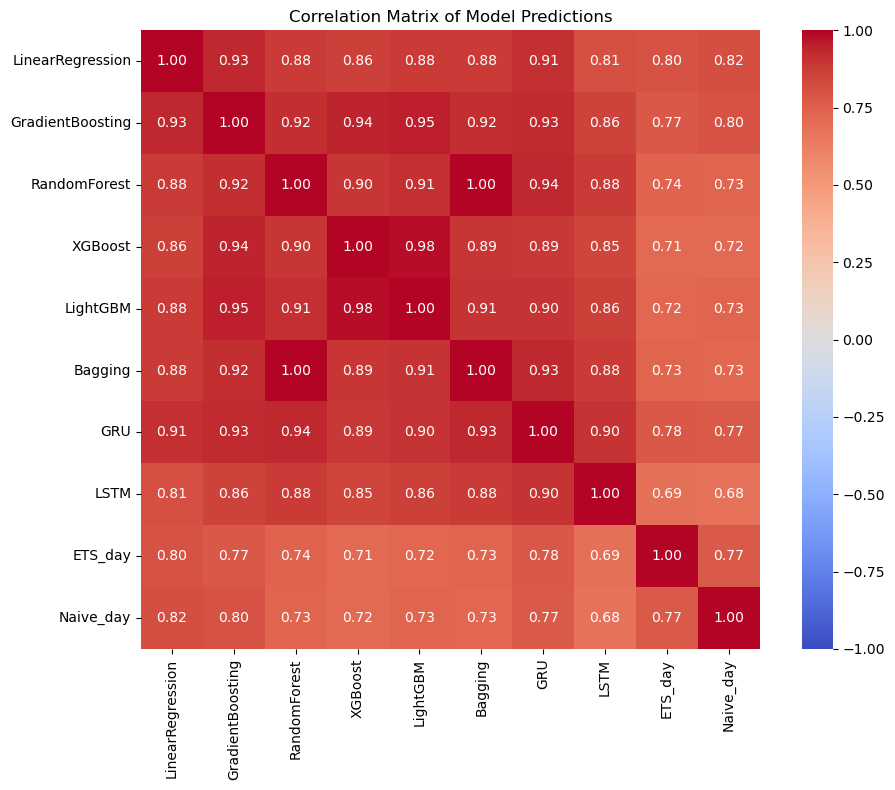

In [16]:
plt.figure(figsize=(10,8))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    square=True
)

plt.title("Correlation Matrix of Model Predictions")
plt.tight_layout()
plt.show()

## Subtensor with only the selected models: LR, GB, GRU, ETS, Naive

In [18]:
print("Shape of Original tensor with 10 models:", pred_tensor_all.shape)

stack_models = ["LinearRegression", "GradientBoosting", "GRU", "ETS_day", "Naive_day"]

print(model_order)
selected_idx = [model_order.index(m) for m in stack_models]
print(selected_idx)

# Make a subtensor with only the selected models
subpred_tensor_all = np.stack(
    [all_frames[name].to_numpy() for name in stack_models],
    axis=2
)
print(subpred_tensor_all.shape)

Shape of Original tensor with 10 models: (8569, 24, 10)
['LinearRegression', 'GradientBoosting', 'RandomForest', 'XGBoost', 'LightGBM', 'Bagging', 'GRU', 'LSTM', 'ETS_day', 'Naive_day']
[0, 1, 6, 8, 9]
(8569, 24, 5)


In [19]:
# Select the base models for the ensemble

selected_idx = [model_order.index(m) for m in stack_models]

metrics = []
results = []

for model_name, idx in zip(stack_models, selected_idx):
    y_pred = pred_tensor_all[:, :, idx]
    metrics = evaluate_multioutput(y_true_aligned, y_pred, y_train_prev)
    row = {
            "exogs": 'price+calendar+exogs',
            "model": model_name
        }
    
    row.update(metrics)
    results.append(row)

results_df = pd.DataFrame(results)

# Check to ensure sorted_summary is as expected
print(results_df[['model', 'MAE_mean', 'RMSE_mean', 'MAPE_mean', 'R2_mean', 'MASE_mean']].sort_values(['RMSE_mean']))


              model  MAE_mean  RMSE_mean  MAPE_mean  R2_mean  MASE_mean
0  LinearRegression     5.569      7.815     16.462    0.608      0.702
1  GradientBoosting     5.856      8.191     17.413    0.570      0.739
2               GRU     6.638      8.691     17.268    0.515      0.837
3           ETS_day     6.308      8.845     16.817    0.498      0.796
4         Naive_day     6.796     10.015     19.526    0.356      0.857


### Equal-weight ensemble

In [21]:
def equal_weight_ensemble(pred_tensor_subset):
    """
    pred_tensor_subset: (samples, horizons, n_models)
    """
    return np.mean(pred_tensor_subset, axis=2)

# Evaluate the equal-weight ensemble strategy
y_pred_equal = equal_weight_ensemble(subpred_tensor_all)

metrics_equal = evaluate_multioutput(y_true_aligned, y_pred_equal, y_train_prev)
print("Equal-weight ensemble:", metrics_equal)

Equal-weight ensemble: {'MAE_mean': 5.24, 'RMSE_mean': 7.393, 'MAPE_mean': 15.641, 'R2_mean': 0.649, 'MASE_mean': 0.661}


### Performance-weighted ensemble 

In [23]:
# Actual validation/calibration MASEs

mase_scores = {
    "LinearRegression": round(results_df.loc[results_df['model']=='LinearRegression', 'MASE_mean'].values[0],4),
    "GradientBoosting": round(results_df.loc[results_df['model']=='GradientBoosting', 'MASE_mean'].values[0],4),
    "GRU": round(results_df.loc[results_df['model']=='GRU', 'MASE_mean'].values[0],4),
    "ETS_day": round(results_df.loc[results_df['model']=='ETS_day', 'MASE_mean'].values[0],4),
    "Naive_day": round(results_df.loc[results_df['model']=='Naive_day', 'MASE_mean'].values[0],4)
}

# Convert inverse MASE into weights
def inverse_mase_weights(mase_scores_dict, selected_models):
    inv = np.array([1.0 / mase_scores_dict[m] for m in selected_models], dtype=float)
    weights = inv / inv.sum()
    return weights


def weighted_average_ensemble(pred_tensor_subset, weights):
    """
    pred_tensor_subset: (samples, horizons, n_models)
    weights: (n_models,)
    """
    weights = np.asarray(weights).reshape(1, 1, -1)
    return np.sum(pred_tensor_subset * weights, axis=2)


# Evaluate the performance-weight ensemble strategy
weights_inv_mase = inverse_mase_weights(mase_scores, stack_models)
print("Inverse-MASE weights:", dict(zip(stack_models, weights_inv_mase)))
print("Normalized weights — Sum Inverse-MASE weights:", round(sum(weights_inv_mase),1))

y_pred_weighted = weighted_average_ensemble(subpred_tensor_all, weights_inv_mase)

metrics_weighted = evaluate_multioutput(y_true_aligned, y_pred_weighted, y_train_prev)
print("\nWeighted-weight ensemble:", metrics_weighted)

Inverse-MASE weights: {'LinearRegression': 0.2227326219987071, 'GradientBoosting': 0.2115809210326013, 'GRU': 0.18680800554730273, 'ETS_day': 0.1964300259335331, 'Naive_day': 0.18244842548785573}
Normalized weights — Sum Inverse-MASE weights: 1.0

Weighted-weight ensemble: {'MAE_mean': 5.227, 'RMSE_mean': 7.375, 'MAPE_mean': 15.628, 'R2_mean': 0.651, 'MASE_mean': 0.659}


## Load 2017 Statistical, ML and GRU predictions

In [25]:
# Load Statistical predictions
dates_stats2017 = np.load("dates_stat2017.npy", allow_pickle=True)

statpred_df2017 = pd.read_csv('stats_preds2017.csv')
# Force timestamp index on statistical predictions
statpred_df2017.index = pd.DatetimeIndex(pd.to_datetime(dates_stats2017))
statpred_df2017 = statpred_df2017.sort_index()
print(f"statpred_df shape: {statpred_df2017.shape}")
print(f"dates_stats2017 len: {len(dates_stats2017)}")

# Load the tensor with ML predictions  
pred_tensor2017 = np.load("pred_tensor_allvars2017.npy")
print(f"ML tensor shape: {pred_tensor2017.shape}")
dates_ml2017 = np.load("dates_ml2017.npy", allow_pickle=True)
print("dates_ml2017 length:",len(dates_ml2017))

y_test2017 = np.load("y_test2017.npy", allow_pickle=True)

redmodel_names = pd.read_csv("redmodel_names.csv", header=None)[0].tolist()
del redmodel_names[0]
print("Models to consider:", redmodel_names)

y_train_full = np.load("y_train_prev2015-16.npy")
print(f"y_train_full shape: {y_train_full.shape}")

# Load GRU predictions
y_pred_gru2017 = np.load("y_pred_gru2017.npy")
dates_gru2017 = np.load("dates_rnn2017.npy", allow_pickle=True)
     
print("\nML first date:", pd.to_datetime(dates_ml2017)[0],"...last date:", pd.to_datetime(dates_ml2017)[-1])
print("Stats first date:", pd.to_datetime(dates_stats2017)[0], "...last date:", pd.to_datetime(dates_stats2017)[-1])
print("GRU first date:", pd.to_datetime(dates_gru2017)[0], "...last date:", pd.to_datetime(dates_gru2017)[-1])


statpred_df shape: (8760, 2)
dates_stats2017 len: 8760
ML tensor shape: (8569, 24, 2)
dates_ml2017 length: 8569
Models to consider: ['LinearRegression', 'GradientBoosting']
y_train_full shape: (17544,)

ML first date: 2017-01-08 00:00:00+01:00 ...last date: 2017-12-31 00:00:00+01:00
Stats first date: 2017-01-01 00:00:00+01:00 ...last date: 2017-12-31 23:00:00+01:00
GRU first date: 2017-01-01 00:00:00+01:00 ...last date: 2017-12-31 00:00:00+01:00


## Create a tensor with all 2017 predictions aligned

In [27]:
stat_frames, valid_stat_dates = build_stat_horizon_frames(statpred_df=statpred_df2017[["ETS_day", "Naive_day"]],
                                                          row_dates=dates_ml2017,
                                                          horizon=24)

gru_df = pd.DataFrame(y_pred_gru2017,
                     index=pd.DatetimeIndex(pd.to_datetime(dates_gru2017)),
                     columns=[f"h{i+1}" for i in range(24)]).sort_index()

gru_df = gru_df.loc[dates_ml2017]

y_true_df = pd.DataFrame(y_test2017,
                         index=pd.DatetimeIndex(pd.to_datetime(dates_ml2017)),
                         columns=[f"h{i+1}" for i in range(24)])


ml_frames = {}
for i, name in enumerate(redmodel_names):
    ml_frames[name] = pd.DataFrame(
        pred_tensor2017[:, :, i],
        index=pd.DatetimeIndex(pd.to_datetime(dates_ml2017)),
        columns=[f"h{i+1}" for i in range(24)]
    )

all_frames = {
    **ml_frames,
    "GRU": gru_df,
    "ETS_day": stat_frames["ETS_day"],
    "Naive_day": stat_frames["Naive_day"],
}

common_dates2017 = pd.DatetimeIndex(dates_ml2017)
for name in all_frames:
    all_frames[name] = all_frames[name].loc[common_dates2017]


pred_tensor_all2017 = np.stack(
    [all_frames[name].to_numpy() for name in stack_models],
    axis=2
)

y_true_aligned2017 = y_true_df.loc[common_dates2017].to_numpy()

print("Final tensor shape:",pred_tensor_all2017.shape)
print("y_true aligned", y_true_aligned2017.shape)
print("Models:", stack_models)
print("Number of common dates:", len(common_dates2017))

Final tensor shape: (8569, 24, 5)
y_true aligned (8569, 24)
Models: ['LinearRegression', 'GradientBoosting', 'GRU', 'ETS_day', 'Naive_day']
Number of common dates: 8569


## Train Ridge/ElasticNet stacking Ensemble on 2017 predictions

In [29]:
# train one meta-model per horizon

def fit_stacking_per_horizon(pred_val_subset, y_val_true, model_type="ridge", alpha=1.0, l1_ratio=0.5):
    """
    pred_val_subset: (samples_val, horizons, n_models)
    y_val_true:      (samples_val, horizons)

    Returns:
        meta_models: list of fitted models, one per horizon
    """
    n_samples, n_horizons, n_models = pred_val_subset.shape
    meta_models = []

    for h in range(n_horizons):
        Xh = pred_val_subset[:, h, :]   # (samples_val, n_models)
        yh = y_val_true[:, h]

        if model_type == "ridge":
            model = Pipeline([
                ("scaler", StandardScaler()),
                ("ridge", Ridge(alpha=alpha, random_state=42))
            ])
        elif model_type == "elasticnet":
            model = Pipeline([
                ("scaler", StandardScaler()),
                ("enet", ElasticNet(alpha=alpha, l1_ratio=l1_ratio, random_state=42, max_iter=10000))
            ])
        else:
            raise ValueError("model_type must be 'ridge' or 'elasticnet'")

        model.fit(Xh, yh)
        meta_models.append(model)

    return meta_models


def predict_stacking_per_horizon(meta_models, pred_test_subset):
    """
    pred_test_subset: (samples_test, horizons, n_models)
    Returns:
        y_pred_meta: (samples_test, horizons)
    """
    n_samples, n_horizons, n_models = pred_test_subset.shape
    y_pred_meta = np.zeros((n_samples, n_horizons))

    for h, model in enumerate(meta_models):
        Xh = pred_test_subset[:, h, :]
        y_pred_meta[:, h] = model.predict(Xh)

    return y_pred_meta


### Ridge stacking ensemble

In [31]:
ridge_models = fit_stacking_per_horizon(pred_val_subset=pred_tensor_all2017,
                                        y_val_true=y_true_aligned2017,
                                        model_type="ridge",
                                        alpha=1.0)

# Evaluate the ridge-stacking performance ensemble strategy on 2018
y_pred_ridge = predict_stacking_per_horizon(ridge_models, subpred_tensor_all)

metrics_ridge = evaluate_multioutput(y_true_aligned, y_pred_ridge, y_train_prev)

print("Ridge stacking:", metrics_ridge)

Ridge stacking: {'MAE_mean': 4.837, 'RMSE_mean': 7.017, 'MAPE_mean': 14.6, 'R2_mean': 0.684, 'MASE_mean': 0.61}


### ElasticNet stacking ensemble

In [33]:
enet_models = fit_stacking_per_horizon(pred_val_subset=pred_tensor_all2017,
                                       y_val_true=y_true_aligned2017,
                                       model_type="elasticnet",
                                       alpha=0.01,
                                       l1_ratio=0.5)

# Evaluate the ElasticNet stacking ensemble strategy on 2018
y_pred_enet = predict_stacking_per_horizon(enet_models, subpred_tensor_all)
metrics_enet = evaluate_multioutput(y_true_aligned, y_pred_enet, y_train_prev)
print("ElasticNet stacking:", metrics_enet)

ElasticNet stacking: {'MAE_mean': 4.837, 'RMSE_mean': 7.017, 'MAPE_mean': 14.612, 'R2_mean': 0.684, 'MASE_mean': 0.61}


### Ridge Coefficients

In [35]:
def extract_linear_meta_coeffs(meta_models, selected_models, kind="ridge"):
    rows = []
    for h, model in enumerate(meta_models, start=1):
        if kind == "ridge":
            coefs = model.named_steps["ridge"].coef_
            intercept = model.named_steps["ridge"].intercept_
        else:
            coefs = model.named_steps["enet"].coef_
            intercept = model.named_steps["enet"].intercept_

        row = {"horizon": h, "intercept": intercept}
        for name, coef in zip(selected_models, coefs):
            row[name] = coef
        rows.append(row)

    return pd.DataFrame(rows)


In [36]:
# Ridge coefficients
df_ridge_coefs = extract_linear_meta_coeffs(ridge_models, stack_models, kind="ridge")
print("Average Ridge coefficients:\n",df_ridge_coefs[["LinearRegression", "GradientBoosting", "GRU", "ETS_day", "Naive_day"]].mean().to_frame().T)

# ElasticNet coefficients
df_elastic_coefs = extract_linear_meta_coeffs(enet_models, stack_models, kind="elasticnet")
print("Average ElasticNet coefficients:\n",df_elastic_coefs[["LinearRegression", "GradientBoosting", "GRU", "ETS_day", "Naive_day"]].mean().to_frame().T)


Average Ridge coefficients:
    LinearRegression  GradientBoosting       GRU   ETS_day  Naive_day
0          4.446176           0.84668  0.804397  4.108784   0.382217
Average ElasticNet coefficients:
    LinearRegression  GradientBoosting       GRU   ETS_day  Naive_day
0          4.328363           0.93101  0.811598  4.085366   0.416232


In [37]:
results_ensembles = pd.DataFrame([
    {"model": "Equal-weight", **metrics_equal},
    {"model": "Inverse-MASE weighted", **metrics_weighted},
    {"model": "Ridge stacking", **metrics_ridge},
    {"model": "ElasticNet stacking", **metrics_enet},
])

results_df = pd.concat([results_df.iloc[:, 1:], results_ensembles], ignore_index=True) 
print(results_df.sort_values('MASE_mean', ascending = False))

                   model  MAE_mean  RMSE_mean  MAPE_mean  R2_mean  MASE_mean
4              Naive_day     6.796     10.015     19.526    0.356      0.857
2                    GRU     6.638      8.691     17.268    0.515      0.837
3                ETS_day     6.308      8.845     16.817    0.498      0.796
1       GradientBoosting     5.856      8.191     17.413    0.570      0.739
0       LinearRegression     5.569      7.815     16.462    0.608      0.702
5           Equal-weight     5.240      7.393     15.641    0.649      0.661
6  Inverse-MASE weighted     5.227      7.375     15.628    0.651      0.659
7         Ridge stacking     4.837      7.017     14.600    0.684      0.610
8    ElasticNet stacking     4.837      7.017     14.612    0.684      0.610


# Uncertainty estimation
## Diebold–Mariano statistical test

In [39]:
from scipy.stats import t
from scipy.stats import norm 
import statsmodels.api as sm 
from statsmodels.stats.sandwich_covariance import cov_hac

# -----------------------------
# Loss functions
# -----------------------------
def loss_series(y_true, y_pred, loss="mae"):
    """
    Returns per-time loss series (n_samples,) for 1D arrays.
    """
    if loss == "mae":
        return np.abs(y_true - y_pred)
    elif loss == "mse":
        return (y_true - y_pred) ** 2
    else:
        raise ValueError("loss must be 'mae' or 'mse'")

# -----------------------------
# Newey-West HAC variance for mean(d)
# -----------------------------
def nw_var_of_mean(d, lag):
    """
    Newey-West estimator of Var(mean(d)) with Bartlett weights.
    d: (T,) loss differential series
    lag: non-negative int
    """
    d = np.asarray(d)
    T = len(d)
    d = d - d.mean()

    # gamma_0
    gamma0 = np.dot(d, d) / T

    # HAC long-run variance
    lrv = gamma0
    for k in range(1, lag + 1):
        w = 1.0 - k / (lag + 1.0)  # Bartlett weight
        gamma_k = np.dot(d[k:], d[:-k]) / T
        lrv += 2.0 * w * gamma_k

    # Var(mean) = lrv / T
    return lrv / T

# -----------------------------
# Diebold–Mariano test (1D series)
# -----------------------------
def dm_test_1d(y_true, y_pred_a, y_pred_b, horizon=1, loss="mae"):
    """
    DM test for a single horizon (1D arrays).
    Returns DM statistic + two-sided p-value.

    horizon: forecast horizon (used to choose HAC lag = horizon-1 by default)
    """
    y_true = np.asarray(y_true).astype(float)
    y_pred_a = np.asarray(y_pred_a).astype(float)
    y_pred_b = np.asarray(y_pred_b).astype(float)

    # differential loss: d_t = L_a - L_b  (negative => A better if loss is error)
    d = loss_series(y_true, y_pred_a, loss=loss) - loss_series(y_true, y_pred_b, loss=loss)

    T = len(d)
    if T < 10:
        return np.nan, np.nan

    # HAC lag choice
    lag = max(horizon - 1, 0)

    var_mean = nw_var_of_mean(d, lag=lag)
    if var_mean <= 0 or np.isnan(var_mean):
        return np.nan, np.nan

    dm_stat = d.mean() / np.sqrt(var_mean)

    # Use t distribution with T-1 df (common in applied papers)
    p_value = 2 * (1 - t.cdf(np.abs(dm_stat), df=T - 1))
    return dm_stat, p_value

# -----------------------------
# DM test for multi-output (n_samples, 24)
# -----------------------------
def dm_test_multioutput(y_true_2d, y_pred_a_2d, y_pred_b_2d, loss="mae"):
    """
    Runs DM test per horizon and overall (averaged loss across horizons).
    Inputs must be shape (n_samples, H), with H=24.

    Returns:
      df_horizons: DM stats per horizon
      overall: dict with overall DM
    """
    y_true_2d = np.asarray(y_true_2d).astype(float)
    y_pred_a_2d = np.asarray(y_pred_a_2d).astype(float)
    y_pred_b_2d = np.asarray(y_pred_b_2d).astype(float)

    assert y_true_2d.shape == y_pred_a_2d.shape == y_pred_b_2d.shape
    T, H = y_true_2d.shape

    rows = []
    for h in range(H):
        dm_stat, p_val = dm_test_1d(
            y_true=y_true_2d[:, h],
            y_pred_a=y_pred_a_2d[:, h],
            y_pred_b=y_pred_b_2d[:, h],
            horizon=h + 1,
            loss=loss
        )
        rows.append({"horizon": h + 1, "DM_stat": dm_stat, "p_value": p_val})

    df_horizons = pd.DataFrame(rows)

    # ---- Overall DM: average loss across horizons per time step ----
    # This gives one loss per forecast origin by averaging across the 24 horizons.
    loss_a = np.mean(loss_series(y_true_2d, y_pred_a_2d, loss=loss), axis=1) if loss in ["mae", "mse"] else None
    loss_b = np.mean(loss_series(y_true_2d, y_pred_b_2d, loss=loss), axis=1) if loss in ["mae", "mse"] else None

    # Implement loss_series for 2D (vectorized) via the same definitions:
    if loss == "mae":
        loss_a = np.mean(np.abs(y_true_2d - y_pred_a_2d), axis=1)
        loss_b = np.mean(np.abs(y_true_2d - y_pred_b_2d), axis=1)
    elif loss == "mse":
        loss_a = np.mean((y_true_2d - y_pred_a_2d) ** 2, axis=1)
        loss_b = np.mean((y_true_2d - y_pred_b_2d) ** 2, axis=1)

    d_overall = loss_a - loss_b

    # For overall, a conservative HAC lag is H-1 (=23)
    var_mean_overall = nw_var_of_mean(d_overall, lag=max(H - 1, 0))
    overall_dm = d_overall.mean() / np.sqrt(var_mean_overall)
    overall_p = 2 * (1 - t.cdf(np.abs(overall_dm), df=len(d_overall) - 1))

    overall = {
        "DM_stat": overall_dm,
        "p_value": overall_p,
        "mean_loss_A": float(np.mean(loss_a)),
        "mean_loss_B": float(np.mean(loss_b)),
        "mean_diff_A_minus_B": float(np.mean(d_overall)),
        "loss": loss
    }

    return df_horizons, overall

In [40]:
model_name='LinearRegression' 
idx = model_order.index(model_name)    
y_pred_firstModel = pred_tensor_all[:, :, idx]


df_dm_h, dm_overall = dm_test_multioutput(y_true_2d=y_true_aligned,  
                                          y_pred_a_2d=y_pred_ridge,     # Model A: Best Ensemble: Elastic Net
                                          y_pred_b_2d=y_pred_firstModel,    # Model B: Best single model: LR
                                          loss="mse")

print("Overall DM:", dm_overall)
print(df_dm_h)

Overall DM: {'DM_stat': -6.179049064493768, 'p_value': 6.743070546377794e-10, 'mean_loss_A': 49.24481013085924, 'mean_loss_B': 61.074387318672294, 'mean_diff_A_minus_B': -11.82957718781305, 'loss': 'mse'}
    horizon   DM_stat       p_value
0         1 -9.745485  0.000000e+00
1         2 -9.241813  0.000000e+00
2         3 -7.987663  1.554312e-15
3         4 -7.757959  9.547918e-15
4         5 -7.524081  5.839773e-14
5         6 -7.445661  1.056932e-13
6         7 -6.598224  4.407985e-11
7         8 -6.357157  2.160232e-10
8         9 -5.980217  2.317672e-09
9        10 -5.688095  1.326855e-08
10       11 -5.581843  2.452428e-08
11       12 -5.498127  3.948801e-08
12       13 -5.742389  9.653442e-09
13       14 -5.850055  5.094514e-09
14       15 -5.964262  2.554817e-09
15       16 -6.084242  1.220646e-09
16       17 -6.071101  1.324391e-09
17       18 -6.127759  9.305841e-10
18       19 -6.247672  4.364773e-10
19       20 -6.277094  3.617151e-10
20       21 -6.341077  2.397063e-10
21 

sig = (df_dm_h["p_value"] < 0.05).mean() * 100
print(f"Significant horizons (%): {sig:.1f}%")

In [42]:
sig = (df_dm_h["p_value"] < 0.05).mean() * 100
print(f"Significant horizons (%): {sig:.1f}%")

Significant horizons (%): 100.0%


## Horizon-wise MAE and RMSE plot

In [44]:
def plot_horizon_wise_errors_side_by_side(y_true, y_pred_model1, y_pred_model2,
                                          model1_name="LinearRegression",
                                          model2_name="Ridge stacking"):
    
    y_true = np.asarray(y_true)
    y_pred_model1 = np.asarray(y_pred_model1)
    y_pred_model2 = np.asarray(y_pred_model2)

    H = y_true.shape[1]
    horizons = np.arange(1, H + 1)

    mae_1 = [np.mean(np.abs(y_true[:, h] - y_pred_model1[:, h])) for h in range(H)]
    mae_2 = [np.mean(np.abs(y_true[:, h] - y_pred_model2[:, h])) for h in range(H)]

    rmse_1 = [np.sqrt(np.mean((y_true[:, h] - y_pred_model1[:, h])**2)) for h in range(H)]
    rmse_2 = [np.sqrt(np.mean((y_true[:, h] - y_pred_model2[:, h])**2)) for h in range(H)]

    fig, axes = plt.subplots(1, 2, figsize=(14,5))

    # ---- MAE ----
    axes[0].plot(horizons, mae_1, marker='o', label=model1_name)
    axes[0].plot(horizons, mae_2, marker='o', label=model2_name)
    axes[0].set_title("Horizon-wise MAE")
    axes[0].set_xlabel("Forecast horizon (hours ahead)")
    axes[0].set_ylabel("MAE")
    axes[0].set_xticks(range(1,25,2))
    axes[0].grid(True, alpha=0.3)
    axes[0].legend()

    # ---- RMSE ----
    axes[1].plot(horizons, rmse_1, marker='o', label=model1_name)
    axes[1].plot(horizons, rmse_2, marker='o', label=model2_name)
    axes[1].set_title("Horizon-wise RMSE")
    axes[1].set_xlabel("Forecast horizon (hours ahead)")
    axes[1].set_ylabel("RMSE")
    axes[1].set_xticks(range(1,25,2))
    axes[1].grid(True, alpha=0.3)
    axes[1].legend()

    axes[0].fill_between(horizons, mae_1, mae_2, alpha=0.2)
    axes[1].fill_between(horizons, rmse_1, rmse_2, alpha=0.2)

    axes[0].set_xticks(range(1,25,2))
    axes[1].set_xticks(range(1,25,2))

    ### Save Figures
    plt.savefig(f"horizon_error_comparison.png", dpi=300, bbox_inches="tight")
    plt.savefig(f"horizon_error_comparison.pdf", bbox_inches="tight")
    
    plt.tight_layout()
    plt.show()

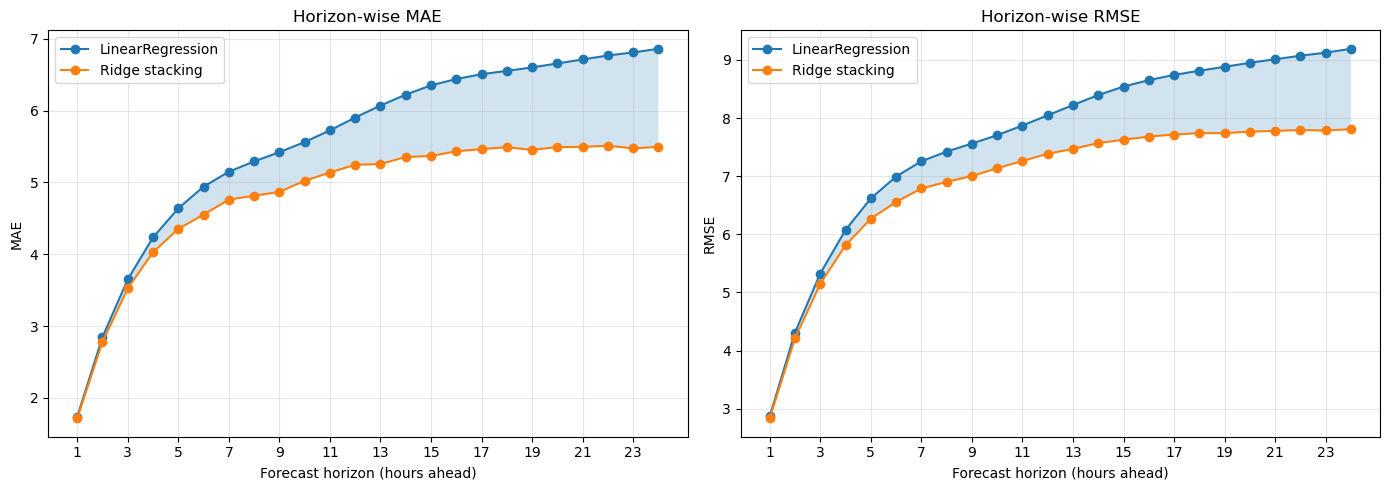

In [45]:
plot_horizon_wise_errors_side_by_side(
    y_true=y_test,
    y_pred_model1=y_pred_firstModel,
    y_pred_model2=y_pred_ridge,
    model1_name="LinearRegression",
    model2_name="Ridge stacking"
)

### A small table of horizon-wise errors to support the figures

In [47]:
def horizon_error_table(y_true, y_pred_model1, y_pred_model2,
                        model1_name="LinearRegression",
                        model2_name="Ridge stacking"):
    y_true = np.asarray(y_true)
    y_pred_model1 = np.asarray(y_pred_model1)
    y_pred_model2 = np.asarray(y_pred_model2)

    H = y_true.shape[1]
    rows = []

    for h in range(H):
        mae_1 = np.mean(np.abs(y_true[:, h] - y_pred_model1[:, h]))
        mae_2 = np.mean(np.abs(y_true[:, h] - y_pred_model2[:, h]))
        rmse_1 = np.sqrt(np.mean((y_true[:, h] - y_pred_model1[:, h])**2))
        rmse_2 = np.sqrt(np.mean((y_true[:, h] - y_pred_model2[:, h])**2))

        rows.append({
            "horizon": h + 1,
            f"{model1_name}_MAE": mae_1,
            f"{model2_name}_MAE": mae_2,
            f"{model1_name}_RMSE": rmse_1,
            f"{model2_name}_RMSE": rmse_2,
        })

    return pd.DataFrame(rows)

df_horizon_errors = horizon_error_table(
    y_true=y_test,
    y_pred_model1=y_pred_firstModel,
    y_pred_model2=y_pred_ridge,
    model1_name="LR",
    model2_name="RDStk"
)

df_horizon_errors['diff_MAE'] = df_horizon_errors.iloc[:,1] - df_horizon_errors.iloc[:,2]
df_horizon_errors['diff_RMSE'] = df_horizon_errors.iloc[:,3] - df_horizon_errors.iloc[:,4]

print(df_horizon_errors)

    horizon    LR_MAE  RDStk_MAE   LR_RMSE  RDStk_RMSE  diff_MAE  diff_RMSE
0         1  1.736039   1.715241  2.864985    2.834457  0.020798   0.030528
1         2  2.845395   2.779370  4.308634    4.210614  0.066025   0.098020
2         3  3.649654   3.524097  5.324551    5.145419  0.125557   0.179132
3         4  4.233317   4.026941  6.073608    5.811697  0.206376   0.261911
4         5  4.638803   4.353009  6.615844    6.267320  0.285793   0.348524
5         6  4.940465   4.551164  6.992832    6.555836  0.389301   0.436996
6         7  5.148706   4.759918  7.254993    6.787412  0.388789   0.467581
7         8  5.292380   4.814940  7.422096    6.901223  0.477440   0.520874
8         9  5.420993   4.867544  7.559988    7.002515  0.553449   0.557473
9        10  5.562237   5.022552  7.704668    7.135032  0.539685   0.569635
10       11  5.724557   5.136966  7.870469    7.261302  0.587591   0.609167
11       12  5.903767   5.245755  8.046822    7.384793  0.658012   0.662030
12       13 

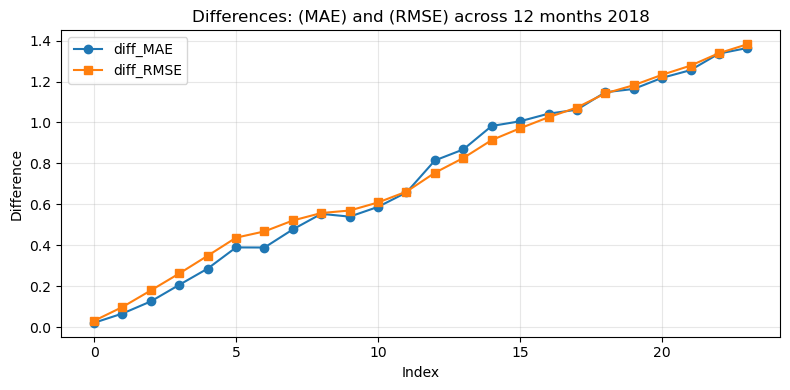

In [48]:
plt.figure(figsize=(8,4))
plt.plot(df_horizon_errors.index, df_horizon_errors['diff_MAE'], label='diff_MAE', marker='o')
plt.plot(df_horizon_errors.index, df_horizon_errors['diff_RMSE'], label='diff_RMSE', marker='s')
plt.xlabel('Index')
plt.ylabel('Difference')
plt.title('Differences: (MAE) and (RMSE) across 12 months 2018')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Time series visualization with the best prediction model (Ridge ensemble)
### Monthly daily average

In [50]:
# y_true_aligned and y_pred_ridge are 2D arrays of shape (8569, 24) (8569 days × 24 hours = 205,656 values), 
# while common_dates only has 8,569 daily timestamps.
# common_dates contains only 358 daily timestamps (from 8 Jan 2018 to 31 Dec 2018)
# This function correctly expands the daily common_dates into an hourly index.
# Handles the 2D shape of the predictions by averaging the 24 hourly values per day — it gives one clean representative line 
# for True Price and one for Ridge Stacking, making the monthly trend much easier to read.


def plot_month_daily_average(y_true_aligned, 
                             y_pred_ridge, 
                             common_dates, 
                             month=1, 
                             figsize=(14, 6)):
    """
    Plot daily average price (mean of 24 hours) for True vs Ridge Stacking.
    This eliminates the spaghetti effect completely.
    """
    # Convert to 2D: (n_days, 24)
    y_true = np.asarray(y_true_aligned).reshape(-1, 24)
    y_pred = np.asarray(y_pred_ridge).reshape(-1, 24)
    
    if len(common_dates) != y_true.shape[0]:
        raise ValueError(f"common_dates has {len(common_dates)} days, "
                         f"but predictions have {y_true.shape[0]} days.")

    # Compute daily averages
    daily_true = y_true.mean(axis=1)
    daily_pred = y_pred.mean(axis=1)

    # Create DataFrame with daily dates
    df_daily = pd.DataFrame({
        'True': daily_true,
        'Predicted': daily_pred
    }, index=common_dates)

    # Filter to requested month
    if isinstance(month, int):
        df_month = df_daily[df_daily.index.month == month]
        month_str = df_month.index[0].strftime("%B %Y")
    else:
        df_month = df_daily[df_daily.index.strftime('%Y-%m') == str(month)]
        month_str = pd.to_datetime(month).strftime("%B %Y")

    if df_month.empty:
        raise ValueError(f"No data found for month {month}")

    # Plot
    plt.figure(figsize=figsize)
    plt.plot(df_month.index, df_month['True'], 
             label='True Price (daily avg)', color='blue', linewidth=2.2)
    plt.plot(df_month.index, df_month['Predicted'], 
             label='Ridge Stacking (daily avg)', color='orange', linewidth=2.2)

    plt.title(f'Day-Ahead Electricity Price Forecasting — {month_str} (Daily Average)', fontsize=15)
    plt.xlabel('Date')
    plt.ylabel('Average Price (€/MWh)')
    plt.legend(loc='upper left')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

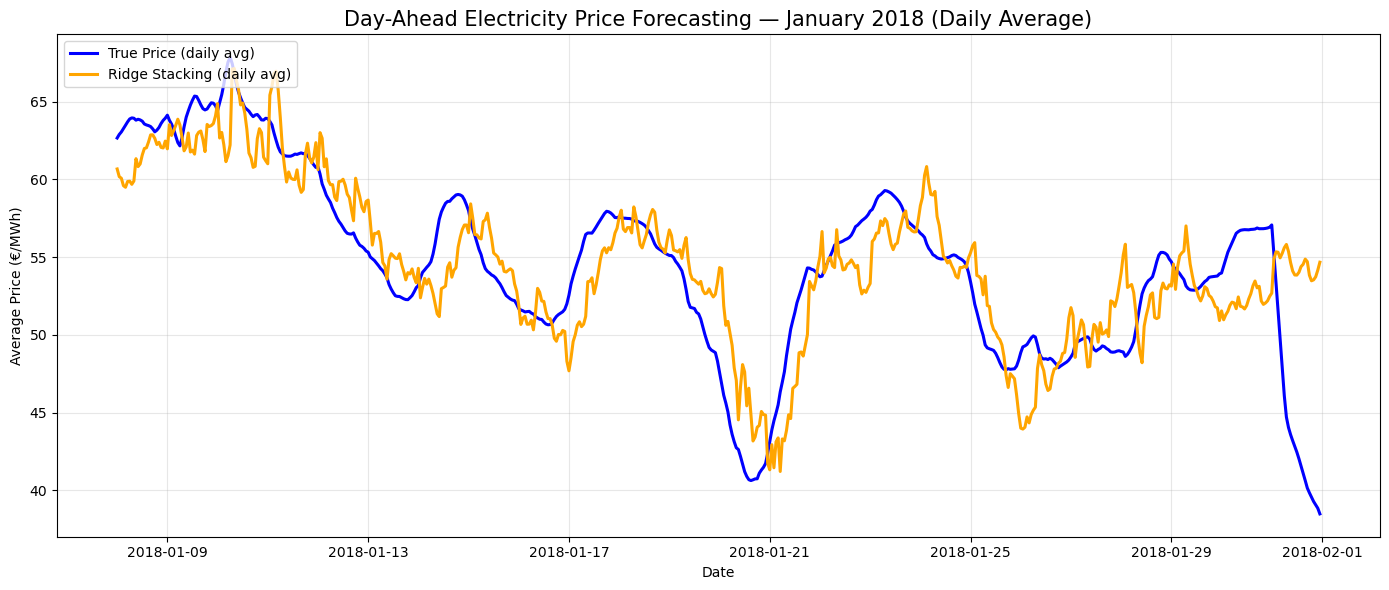

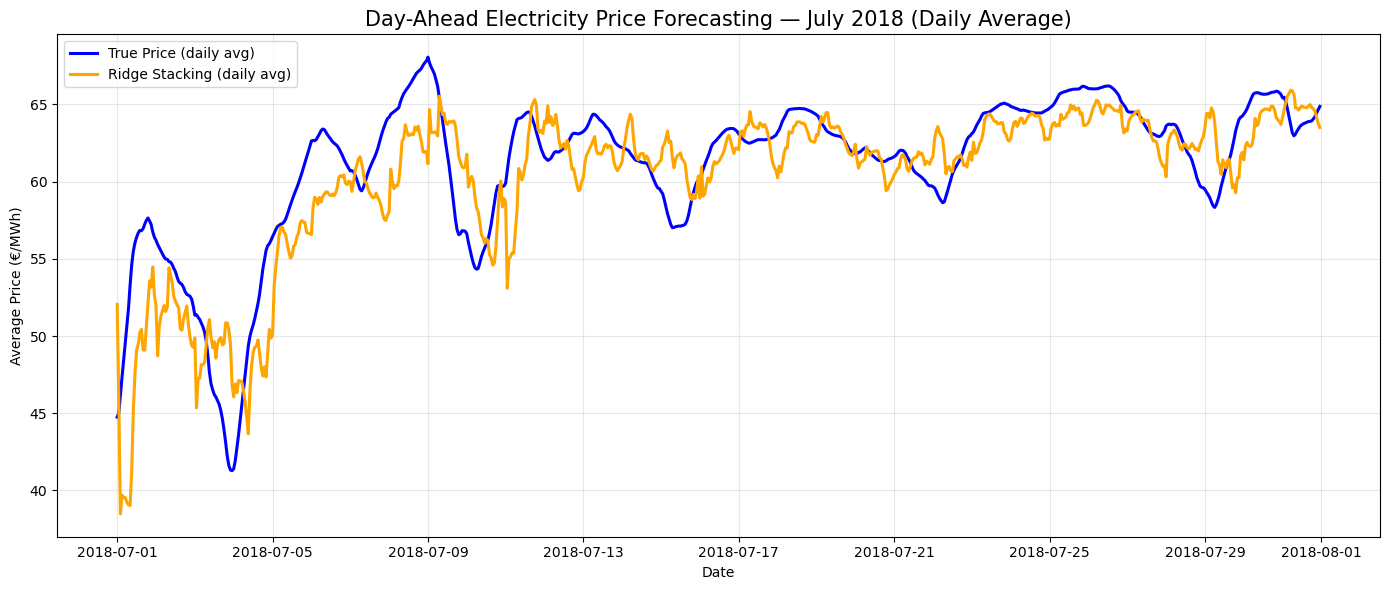

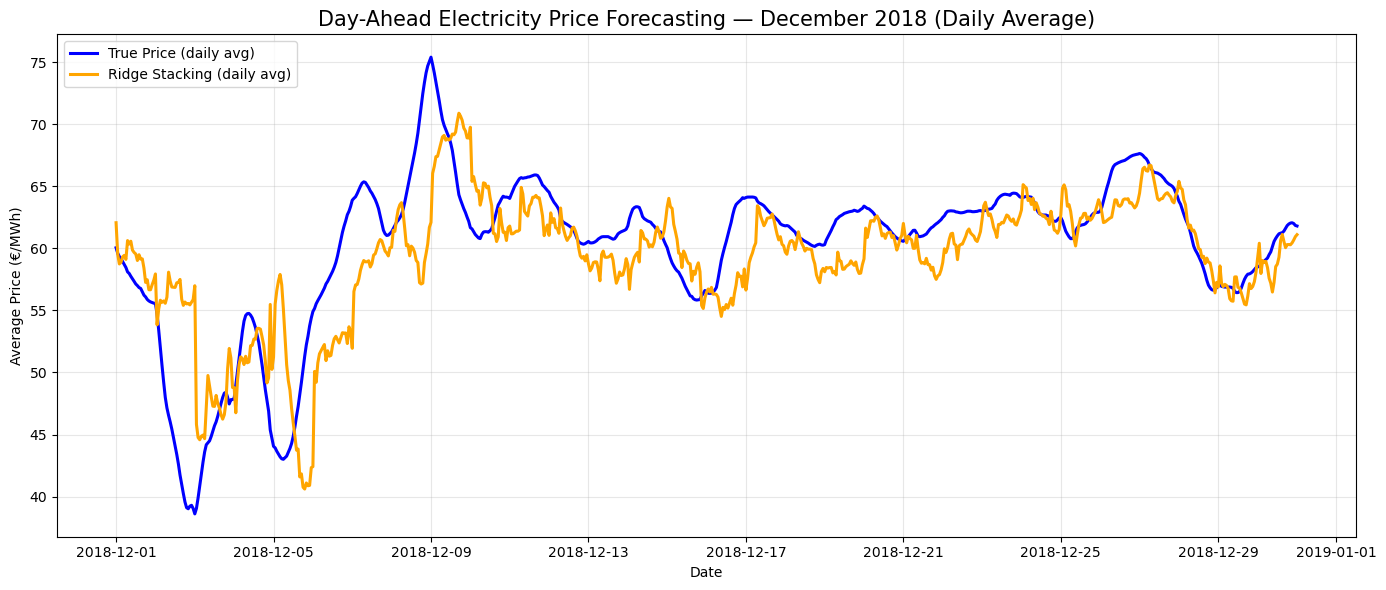

In [58]:
# January 2018
plot_month_daily_average(y_true_aligned, y_pred_ridge, common_dates, month=1)

# July 2018
plot_month_daily_average(y_true_aligned, y_pred_ridge, common_dates, month=7)

# December 2018
plot_month_daily_average(y_true_aligned, y_pred_ridge, common_dates, month=12)